In [1]:
pip install netCDF4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s eta 0:00:00


In [2]:
pip install eofs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00


In [3]:
pip install pyshp

In [6]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import eofs
from eofs.standard import Eof
import shapefile
from datetime import datetime, timedelta
import datetime
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Adicione esta linha para importar a função make_axes_locatable


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
fn = '/content/drive/MyDrive/Colab Notebooks/ERA5/'


file_paths = ['era5_XXL_2003.nc', 'era5_XXL_2004.nc', 'era5_XXL_2005.nc', 'era5_XXL_2006.nc',
              'era5_XXL_2007.nc', 'era5_XXL_2008.nc', 'era5_XXL_2009.nc', 'era5_XXL_2010.nc',
              'era5_XXL_2011.nc', 'era5_XXL_2012.nc', 'era5_XXL_2013.nc', 'era5_XXL_2014.nc',
              'era5_XXL_2015.nc', 'era5_XXL_2016.nc', 'era5_XXL_2017.nc', 'era5_XXL_2018.nc',
              'era5_XXL_2019.nc' ,'era5_XXL_2020.nc', 'era5_XXL_2021.nc',
              'era5_XXL_2022.nc',
              'era5_XXL_2023.nc']

ds = [nc.Dataset(fn+file_path, 'r') for file_path in file_paths]
ds_mask = nc.Dataset(fn+'era5_landseamask.nc', 'r')


In [ ]:
# Concatenar os datasets ao longo da dimensão de tempo
lat0 = ds[0]['latitude']
lon0 = ds[0]['longitude']
time = np.concatenate([ds[i]['time'][:] for i in range(len(ds))])
u = np.concatenate([ds[i]['u10'][:] for i in range(len(ds))])
v = np.concatenate([ds[i]['v10'][:] for i in range(len(ds))])
base_date = datetime.datetime(1900, 1, 1, 0, 0, 0)
time_datetime = [base_date + timedelta(hours=int(t)) for t in time]

In [ ]:


# Calcular a média diária dos dados
daily_bins = np.arange(time[0], time[-1], 24)  # Cria intervalos de 24 horas
daily_u = np.nanmean(np.array(u).reshape(-1, 24, u.shape[1], u.shape[2]), axis=1)  # Calcula a média ao longo do eixo das horas
daily_v = np.nanmean(np.array(v).reshape(-1, 24, v.shape[1], v.shape[2]), axis=1)  # Calcula a média ao longo do eixo das horas

daily_time_datetime = [base_date + timedelta(hours=int(t)) for t in daily_bins]


In [ ]:
np.shape(u), np.shape(daily_u)


((184080, 97, 121), (7670, 97, 121))

In [ ]:
mask_data = np.array(ds_mask['lsm'][:]).squeeze()
mask_data[mask_data > 0.3] = 1
mask_data[mask_data <= 0.3] = 0
mask_data[29:35, 0:4] = 1
mask_data[39:41, 40:42] = 1
mask_data[29:33, 45:50] = 1
mask_data[33, 40:49] = 1
mask_data[34, 40:48] = 1
mask_data[35, 40:46] = 1

replicated_mask_data = np.repeat(np.expand_dims(mask_data, axis=0), 7670, axis=0)


In [ ]:
np.shape(replicated_mask_data)

(7670, 97, 121)

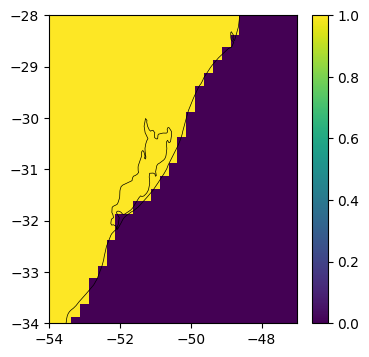

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=100)

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)
    ax.plot(x, y, color ='k', linewidth = 0.5)

q = ax.pcolormesh(lon0, lat0,mask_data)
#ax.set_ylim(np.min(lat0), np.max(lat0))
#ax.set_xlim(np.min(lon0), np.max(lon0))
ax.set_ylim([-34, -28])
ax.set_xlim([-54, -47])

fig.colorbar(q)

In [ ]:


uv_complexo = daily_u + 1j * daily_v
uv_anom = uv_complexo - np.mean(uv_complexo, axis=0)
uv_anom = np.ma.masked_array(uv_anom, mask=replicated_mask_data)

coslat = np.cos(np.deg2rad(lat0))
wgts = np.sqrt(coslat)[..., np.newaxis]

solver = Eof(uv_anom, weights = wgts)#
eofs = solver.eofsAsCovariance()
pcs = solver.pcs()
variance_fractions = solver.varianceFraction()


<ipython-input-14-e3843ca7dd24>:8: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(uv_anom, weights = wgts)#


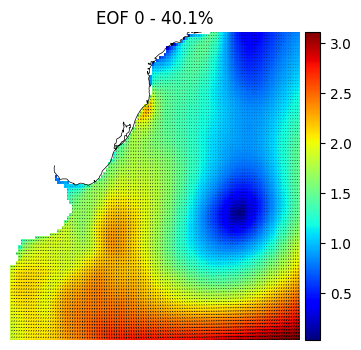

In [ ]:
idx = 0

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
divider = make_axes_locatable(ax)

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)
    ax.plot(x, y, color ='k', linewidth = 0.5)

eofs_u = eofs.real
eofs_v = eofs.imag

pcs_u = pcs.real
pcs_v = pcs.imag

pega_u = eofs_u[idx]
pega_v = eofs_v[idx]


ax.set_title('EOF ' +str(idx) + ' - ' + str(np.round(variance_fractions[idx]*100, 1))+'%')
q = ax.pcolormesh(lon0, lat0, np.abs(eofs[idx]), cmap = 'jet')
ax.quiver(lon0, lat0, pega_u, pega_v)
ax.axis('off')
ax.set_ylim(np.min(lat0), np.max(lat0))
ax.set_xlim(np.min(lon0), np.max(lon0))
#q = ax.pcolormesh(lon0, lat0, np.abs(eofs[3]), shading='auto', cmap ='jet')
#ax.quiver(lon0, lat0, pega_u, pega_v)
#ax.set_ylim([-34, -28])
#ax.set_xlim([-54, -47])


cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(q, cax=cax)


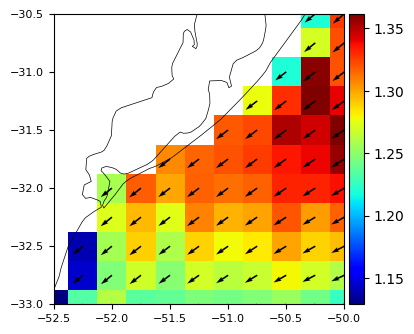

In [ ]:
idx = 6



fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
divider = make_axes_locatable(ax)

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)
    ax.plot(x, y, color ='k', linewidth = 0.5)

eofs_u = eofs.real
eofs_v = eofs.imag

pcs_u = pcs.real
pcs_v = pcs.imag

pega_u = eofs_u[idx]
pega_v = eofs_v[idx]


#ax.set_title('EOF ' +str(idx) + ' - ' + str(np.round(variance_fractions[idx]*100, 1))+'%')

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[idx, 25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)


#ax.annotate('EOF ' +str(idx) + ' - ' + str(np.round(variance_fractions[idx]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(corr[idx])/1000, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

q = ax.pcolormesh(lon0[42:53], lat0[30:41], np.abs(eofs[idx, 30:41, 42:53]), cmap = 'jet')
ax.quiver(lon0[42:53], lat0[30:41], pega_u[30:41, 42:53], pega_v[30:41, 42:53])
ax.axis('equal')
ax.set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax.set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
#ax.set_ylim([-34, -28])
#ax.set_xlim([-54, -48])
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(q, cax=cax)


In [ ]:
11.69/10.2

1.146078431372549

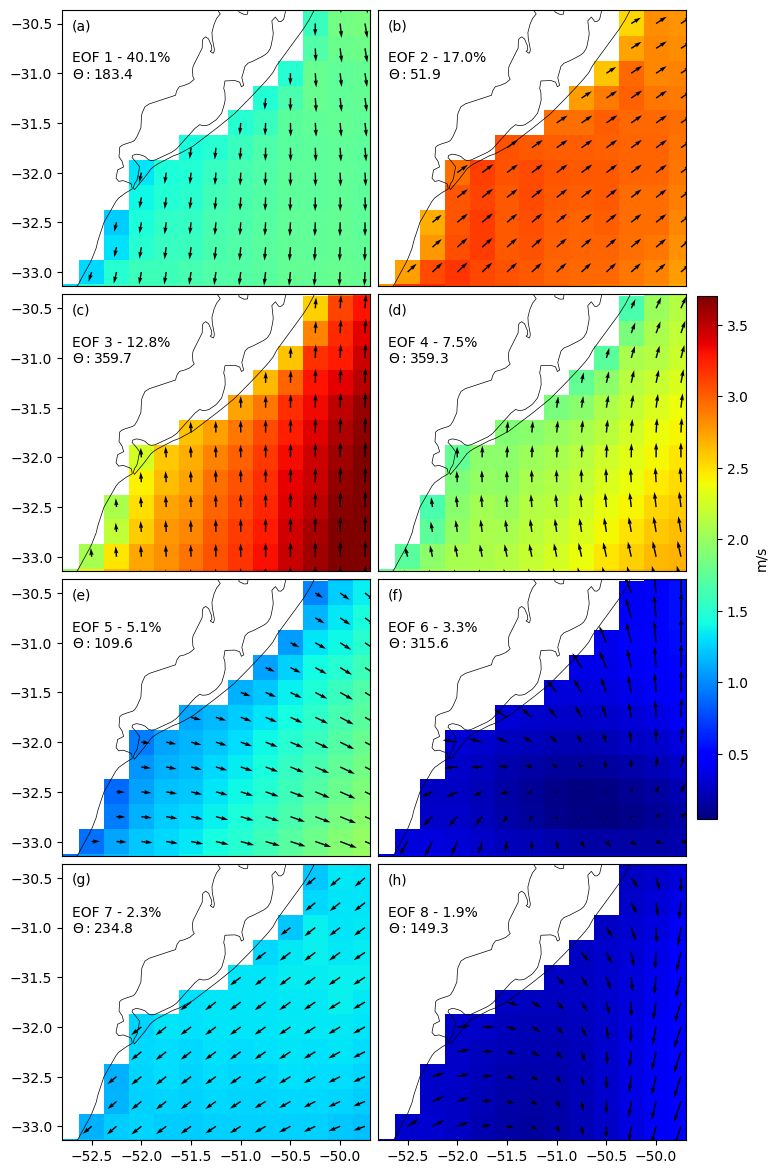

In [ ]:
#

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)

fig, ax = plt.subplots(4,2, figsize=(6*1.14, 10.2*1.14), dpi=100, constrained_layout = True)
cax = fig.add_axes([1.01, 0.3, 0.03, 0.45])

#0
ax[0,0].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[0]
pega_v = eofs_v[0]
q = ax[0,0].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[0][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[0,0].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[0,0].axis('equal')
ax[0,0].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[0,0].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[0,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[0][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[0,0].annotate('(a)\n\nEOF ' +str(1) + ' - ' + str(np.round(variance_fractions[0]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))


#1
ax[0,1].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[1]
pega_v = eofs_v[1]
q = ax[0,1].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[1][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[0,1].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[0,1].axis('equal')
ax[0,1].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[0,1].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[0,1].axes.get_xaxis().set_visible(False)
ax[0,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[1][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[0,1].annotate('(b)\n\nEOF ' +str(2) + ' - ' + str(np.round(variance_fractions[1]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))




#2
ax[1,0].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[2]
pega_v = eofs_v[2]
q = ax[1,0].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[2][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[1,0].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[1,0].axis('equal')
ax[1,0].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[1,0].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[1,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[2][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[1,0].annotate('(c)\n\nEOF ' +str(3) + ' - ' + str(np.round(variance_fractions[2]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))



#3
ax[1,1].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[3]
pega_v = eofs_v[3]
q = ax[1,1].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[3][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[1,1].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[1,1].axis('equal')
ax[1,1].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[1,1].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[1,1].axes.get_xaxis().set_visible(False)
ax[1,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[3][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[1,1].annotate('(d)\n\nEOF ' +str(4) + ' - ' + str(np.round(variance_fractions[3]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))




#4
ax[2,0].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[4]
pega_v = eofs_v[4]
q = ax[2,0].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[4][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[2,0].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[2,0].axis('equal')
ax[2,0].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[2,0].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[2,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[4][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[2,0].annotate('(e)\n\nEOF ' +str(5) + ' - ' + str(np.round(variance_fractions[4]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))





#5
ax[2,1].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[5]
pega_v = eofs_v[5]
q = ax[2,1].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[5][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[2,1].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[2,1].axis('equal')
ax[2,1].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[2,1].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[2,1].axes.get_xaxis().set_visible(False)
ax[2,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[5][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[2,1].annotate('(f)\n\nEOF ' +str(6) + ' - ' + str(np.round(variance_fractions[5]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))



#6
ax[3,0].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[6]
pega_v = eofs_v[6]
q = ax[3,0].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[6][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[3,0].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[3,0].axis('equal')
ax[3,0].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[3,0].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[6][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[3,0].annotate('(g)\n\nEOF ' +str(7) + ' - ' + str(np.round(variance_fractions[6]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))



#7
ax[3,1].plot(x, y, color = 'k', linewidth = 0.5)
eofs_u = eofs.real
eofs_v = eofs.imag
pega_u = eofs_u[7]
pega_v = eofs_v[7]
q = ax[3,1].pcolormesh(lon0[41:54], lat0[29:42], np.abs(eofs[7][29:42, 41:54]), shading='auto', cmap ='jet', vmin = 0.04, vmax = 3.7)
ax[3,1].quiver(lon0[41:54], lat0[29:42], pega_u[29:42, 41:54], pega_v[29:42, 41:54])
ax[3,1].axis('equal')
ax[3,1].set_ylim(np.min(lat0[30:41]), np.max(lat0[30:41]))
ax[3,1].set_xlim(np.min(lon0[42:53]), np.max(lon0[42:53]))
ax[3,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(eofs[7][30:41, 42:53])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[3,1].annotate('(h)\n\nEOF ' +str(8) + ' - ' + str(np.round(variance_fractions[7]*100, 1))+'% \n' +'$\Theta: $'+str(angle_north), xy = (-52.7, -31.05))



fig.colorbar(q, cax=cax, label = 'm/s')

In [ ]:
print(np.nanmean(np.abs(eofs[0][29:42, 41:54])), np.nanmean(np.abs(eofs[2][29:42, 41:54])))

1.6535480634364035 3.1021092815680933


In [ ]:
print(np.nanmean([np.abs(eofs[4][29:42, 41:54]), np.abs(eofs[5][29:42, 41:54]), np.abs(eofs[7][29:42, 41:54])]))



0.6627343429826156


In [ ]:
print(daily_time_datetime[7636], daily_time_datetime[7637])


2023-11-28 00:00:00 2023-11-29 00:00:00


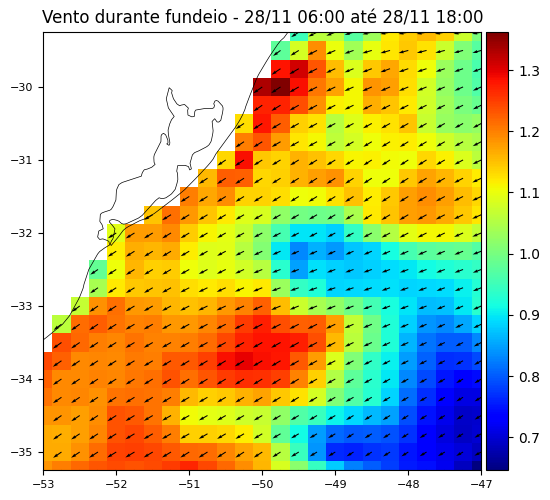

In [ ]:
u_fundeio = daily_u[7636, :,:]
v_fundeio = daily_v[7636, :,:]

uv_fundeio_complexo = u_fundeio + 1j * v_fundeio
uv_fundeio_complexo = np.ma.masked_array(uv_fundeio_complexo, mask=mask_data)

uv_fundeio_complexo = uv_fundeio_complexo - np.mean(uv_complexo, axis=0)




fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
divider = make_axes_locatable(ax)

sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()

# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)
    ax.plot(x, y, color = 'k', linewidth = 0.5)


ax.set_title('Vento durante fundeio - 28/11 06:00 até 28/11 18:00')

#ax.quiver(lon0, lat0, uv_fundeio_anom.real, uv_fundeio_anom.imag)
ax.pcolormesh(lon0[40:65], lat0[25:50], np.abs(uv_fundeio_complexo[25:50, 40:65]), cmap = 'jet')
#ax.quiver(lon0, lat0, u_fundeio, v_fundeio)
ax.quiver(lon0[40:65], lat0[25:50], uv_fundeio_complexo.real[25:50, 40:65], uv_fundeio_complexo.imag[25:50, 40:65], angles = 'xy')
ax.axis('equal')
ax.set_ylim(np.min(lat0[25:50]), np.max(lat0[25:50]))
ax.set_xlim(np.min(lon0[40:65]), np.max(lon0[40:65]))
#ax.set_ylim([-33.2, -31.3])
#ax.set_xlim([-52.7, -50.6])
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(q, cax=cax)

In [ ]:
# Inicializar uma lista para armazenar os MSEs
mses = []
corr = []


# Calcular o MSE para cada modo EOF
for i in range(eofs_u.shape[0]):
    diff = eofs[i, 34:41, 42:50].flatten() - uv_fundeio_complexo[34:41, 42:50].flatten()

    cov_matrix = np.mean(eofs[i, 34:41, 42:50].flatten() * np.conjugate(uv_fundeio_complexo[34:41, 42:50].flatten()))
    std_x = np.std(eofs[i, 34:41, 42:50].flatten())
    std_y = np.std(uv_fundeio_complexo[34:41, 42:50].flatten())
    coefcor = cov_matrix / np.sqrt(std_x * std_y)
    # Calcular o erro médio
    mse = np.mean(np.abs(diff))
    mses.append(mse)
    corr.append(coefcor)


print(np.argmin(mses), np.argmax(corr))




6 6


In [ ]:
np.abs(corr[0])

52.931558549436346

In [ ]:
mes = []


for i in range(12):
    g = []
    for j, t in enumerate(daily_time_datetime):
        if t.month == i+1:
            g.append(uv_anom[j])
    g = np.array(g)
    mes.append(g)

In [ ]:
mensal_eofs = []
mensal_variance = []

for i in range(12):
  print(i)
  replicated_mask_data = np.repeat(np.expand_dims(mask_data, axis=0), len(mes[i]), axis=0)
  mes_masked = np.ma.masked_array(mes[i], mask=replicated_mask_data)

  solver = Eof(mes_masked, weights = wgts)#
  eofs_1 = solver.eofsAsCovariance()
  variance_fractions_1 = solver.varianceFraction()
  mensal_eofs.append(eofs_1)
  mensal_variance.append(variance_fractions_1)


0


<ipython-input-20-ddb9fae440a3>:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(mes_masked, weights = wgts)#


1


<ipython-input-20-ddb9fae440a3>:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(mes_masked, weights = wgts)#


2


...

<ipython-input-20-ddb9fae440a3>:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(mes_masked, weights = wgts)#


10


<ipython-input-20-ddb9fae440a3>:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(mes_masked, weights = wgts)#


11


<ipython-input-20-ddb9fae440a3>:9: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  solver = Eof(mes_masked, weights = wgts)#


In [ ]:
mensal_mses = []
mensal_corr = []
mensal_r2 = []
for t in range(12):
  mses = []
  corr = []
  r2_save = []
  # Calcular o MSE para cada modo EOF
  for i in range(mensal_eofs[t].shape[0]):
      # Calcular a diferença entre as matrizes
      diff = mensal_eofs[t][i, 34:41, 42:50].flatten() - uv_fundeio_complexo[34:41, 42:50].flatten()
      #calcula o R2
      ss_res = np.nansum(diff**2)
      ss_tot = np.nansum((mensal_eofs[t][i, 34:41, 42:50].flatten() - np.nanmean(mensal_eofs[t][i, 34:41, 42:50].flatten()))**2)
      r2 = 1 - (np.abs(ss_res) / np.abs(ss_tot))
      #coeficiente de correlação
      cov_matrix = np.nanmean(mensal_eofs[t][i, 34:41, 42:50].flatten() * np.conjugate(uv_fundeio_complexo[34:41, 42:50].flatten()))
      std_x = np.nanstd(mensal_eofs[t][i, 34:41, 42:50].flatten())
      std_y = np.nanstd(uv_fundeio_complexo[34:41, 42:50].flatten())
      coefcor = cov_matrix / np.sqrt(std_x * std_y)

      mse = np.nanmean(np.abs(diff))
      mses.append(mse)
      corr.append(coefcor)
      r2_save.append(r2)
  mensal_mses.append(mses)
  mensal_corr.append(corr)
  mensal_r2.append(r2_save)
  # Encontrar o índice do MSE mínimo e máximo
  print(np.argmin(mses[:10]), np.argmax(corr[:10]))


1 1
2 2
2 2
1 1
1 1
1 1
2 2
3 3
1 1
1 1
2 2
1 1


In [ ]:
mensal_r2[0][1], np.sqrt(-mensal_r2[9][1])

(-800.0078188427195, 47.02399193794788)

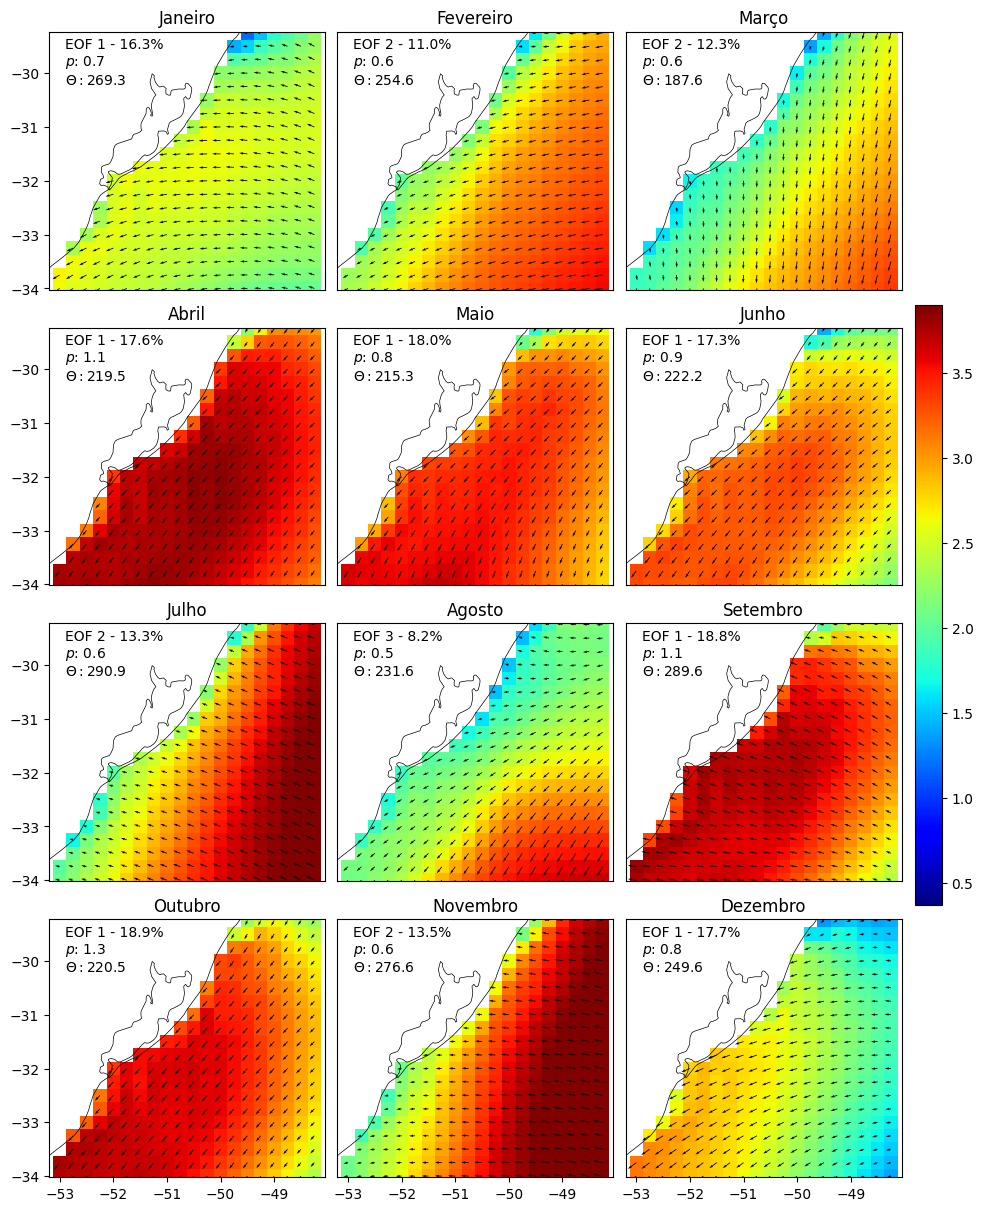

In [ ]:
sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)

fig, ax = plt.subplots(4,3, figsize=(9, 12), dpi=100, constrained_layout = True)
cax = fig.add_axes([1.01, 0.25, 0.03, 0.5])


ax[0,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,0].set_title('Janeiro')
eofs_u_1 = mensal_eofs[0].real
eofs_v_1 = mensal_eofs[0].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[0,0].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[0][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,0].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[0,0].axis('equal')
ax[0,0].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[0,0].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[0,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[0][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[0,0].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[0][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[0][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[0,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,1].set_title('Fevereiro')
eofs_u_1 = mensal_eofs[1].real
eofs_v_1 = mensal_eofs[1].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[0,1].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[1][2][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,1].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[0,1].axis('equal')
ax[0,1].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[0,1].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[0,1].axes.get_xaxis().set_visible(False)
ax[0,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[1][2][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[0,1].annotate('EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[1][2]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[1][2])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

ax[0,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,2].set_title('Março')
eofs_u_1 = mensal_eofs[2].real
eofs_v_1 = mensal_eofs[2].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[0,2].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[2][2][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,2].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[0,2].axis('equal')
ax[0,2].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[0,2].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[0,2].axes.get_xaxis().set_visible(False)
ax[0,2].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[2][2][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[0,2].annotate('EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[2][2]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[2][2])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[1,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,0].set_title('Abril')
eofs_u_1 = mensal_eofs[3].real
eofs_v_1 = mensal_eofs[3].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,0].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[3][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,0].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[1,0].axis('equal')
ax[1,0].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[1,0].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[1,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[3][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[1,0].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[3][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[3][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[1,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,1].set_title('Maio')
eofs_u_1 = mensal_eofs[4].real
eofs_v_1 = mensal_eofs[4].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,1].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[4][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,1].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[1,1].axis('equal')
ax[1,1].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[1,1].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[1,1].axes.get_xaxis().set_visible(False)
ax[1,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[4][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[1,1].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[4][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[4][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[1,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,2].set_title('Junho')
eofs_u_1 = mensal_eofs[5].real
eofs_v_1 = mensal_eofs[5].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,2].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[5][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,2].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[1,2].axis('equal')
ax[1,2].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[1,2].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[1,2].axes.get_xaxis().set_visible(False)
ax[1,2].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[5][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[1,2].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[5][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[5][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[2,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,0].set_title('Julho')
eofs_u_1 = mensal_eofs[6].real
eofs_v_1 = mensal_eofs[6].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[2,0].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[6][2][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,0].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[2,0].axis('equal')
ax[2,0].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[2,0].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[2,0].axes.get_xaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[6][2][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[2,0].annotate('EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[6][2]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[6][2])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

ax[2,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,1].set_title('Agosto')
eofs_u_1 = mensal_eofs[7].real
eofs_v_1 = mensal_eofs[7].imag
pega_u_1 = eofs_u_1[3]
pega_v_1 = eofs_v_1[3]
q = ax[2,1].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[7][3][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,1].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[2,1].axis('equal')
ax[2,1].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[2,1].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[2,1].axes.get_xaxis().set_visible(False)
ax[2,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[7][3][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[2,1].annotate('EOF ' +str(3) + ' - ' + str(np.round(mensal_variance[7][3]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[7][3])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[2,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,2].set_title('Setembro')
eofs_u_1 = mensal_eofs[8].real
eofs_v_1 = mensal_eofs[8].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[2,2].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[8][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,2].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[2,2].axis('equal')
ax[2,2].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[2,2].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[2,2].axes.get_xaxis().set_visible(False)
ax[2,2].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[8][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[2,2].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[8][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[8][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

ax[3,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,0].set_title('Outubro')
eofs_u_1 = mensal_eofs[9].real
eofs_v_1 = mensal_eofs[9].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[3,0].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[9][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,0].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[3,0].axis('equal')
ax[3,0].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[3,0].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[9][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[3,0].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[9][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[9][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

ax[3,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,1].set_title('Novembro')
eofs_u_1 = mensal_eofs[10].real
eofs_v_1 = mensal_eofs[10].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[3,1].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[10][2][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,1].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[3,1].axis('equal')
ax[3,1].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[3,1].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[3,1].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[10][2][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[3,1].annotate('EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[10][2]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[10][2])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))


ax[3,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,2].set_title('Dezembro')
eofs_u_1 = mensal_eofs[11].real
eofs_v_1 = mensal_eofs[11].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[3,2].pcolormesh(lon0[40:60], lat0[25:45], np.abs(mensal_eofs[11][1][25:45, 40:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,2].quiver(lon0[40:60], lat0[25:45], pega_u_1[25:45, 40:60], pega_v_1[25:45, 40:60])
ax[3,2].axis('equal')
ax[3,2].set_ylim(np.min(lat0[25:45]), np.max(lat0[25:45]))
ax[3,2].set_xlim(np.min(lon0[40:60]), np.max(lon0[40:60]))
ax[3,2].axes.get_yaxis().set_visible(False)

angle_degrees = np.degrees(np.angle(np.nanmean(mensal_eofs[11][1][25:45, 40:60])))
if angle_degrees < 0:
    angle_degrees += 360

# Ajustar para que o ângulo seja em relação ao norte verdadeiro
angle_north = np.round((450 - angle_degrees) % 360, 1)
ax[3,2].annotate('EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[11][1]*100, 1))+'% \n$\it{p }$: ' + str(np.round(np.abs(mensal_corr[11][1])/100, 1))+'\n$\Theta: $'+str(angle_north), xy = (-52.9, -30.2))

fig.colorbar(q, cax=cax)


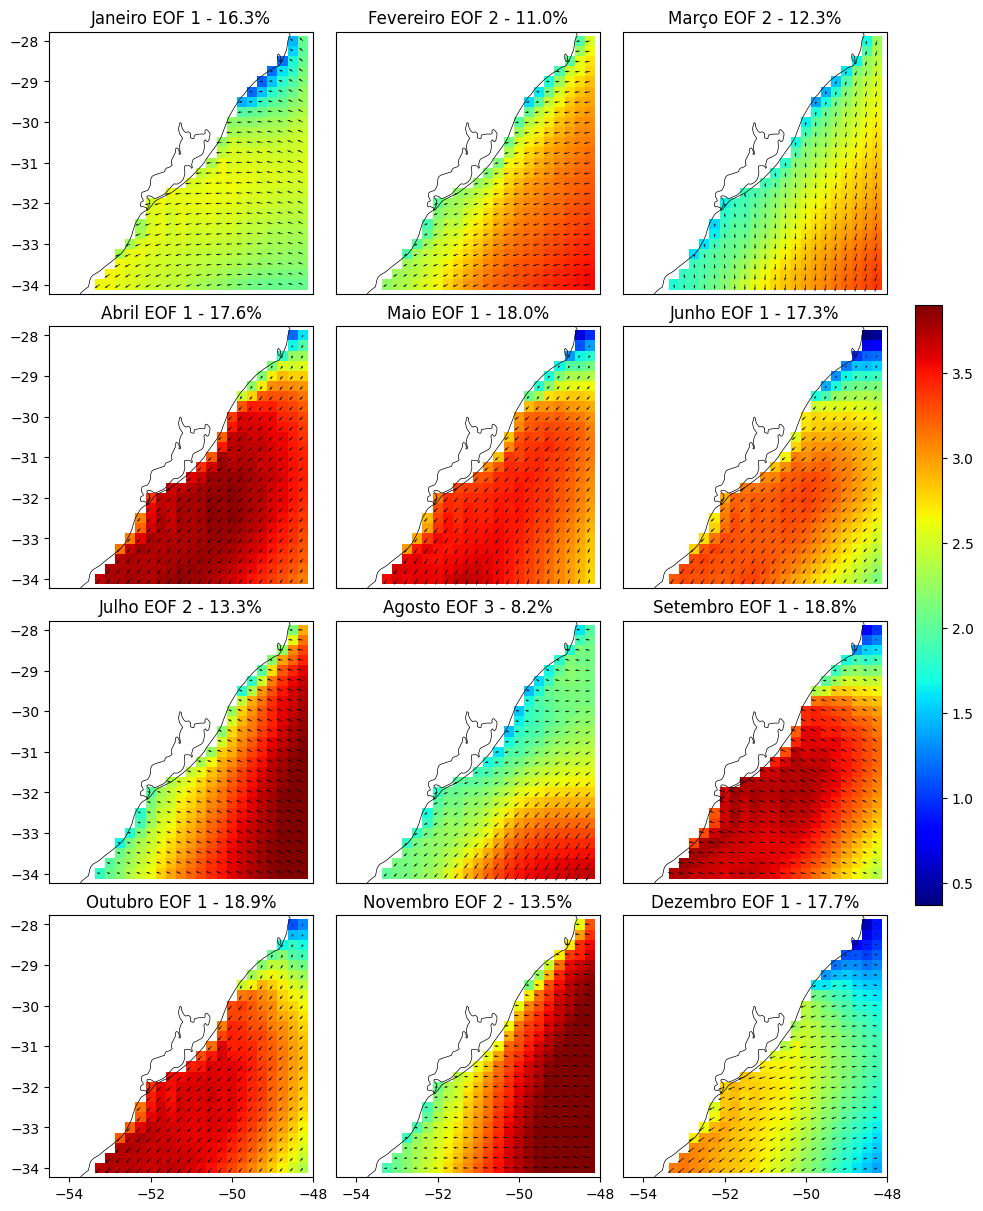

In [ ]:
sf = shapefile.Reader('/content/drive/MyDrive/Colab Notebooks/ERA5/SouthAmerica_coastline_line_degdec.shp')

# Obter os registros do shapefile
records = sf.records()


# Obter os polígonos do shapefile
shapes = sf.shapes()

# Plotar os polígonos
for shape in shapes:
    x, y = zip(*shape.points)

fig, ax = plt.subplots(4,3, figsize=(9, 12), dpi=100, constrained_layout = True)
cax = fig.add_axes([1.01, 0.25, 0.03, 0.5])


ax[0,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,0].set_title('Janeiro EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[0][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[0].real
eofs_v_1 = mensal_eofs[0].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[0,0].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[0][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,0].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[0,0].axis('equal')
ax[0,0].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[0,0].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[0,0].axes.get_xaxis().set_visible(False)

ax[0,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,1].set_title('Fevereiro EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[1][2]*100, 1))+'%')
eofs_u_1 = mensal_eofs[1].real
eofs_v_1 = mensal_eofs[1].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[0,1].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[1][2][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,1].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[0,1].axis('equal')
ax[0,1].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[0,1].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[0,1].axes.get_xaxis().set_visible(False)
ax[0,1].axes.get_yaxis().set_visible(False)

ax[0,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[0,2].set_title('Março EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[2][2]*100, 1))+'%')
eofs_u_1 = mensal_eofs[2].real
eofs_v_1 = mensal_eofs[2].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[0,2].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[2][2][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[0,2].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[0,2].axis('equal')
ax[0,2].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[0,2].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[0,2].axes.get_xaxis().set_visible(False)
ax[0,2].axes.get_yaxis().set_visible(False)

ax[1,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,0].set_title('Abril EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[3][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[3].real
eofs_v_1 = mensal_eofs[3].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,0].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[3][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,0].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[1,0].axis('equal')
ax[1,0].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[1,0].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[1,0].axes.get_xaxis().set_visible(False)

ax[1,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,1].set_title('Maio EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[4][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[4].real
eofs_v_1 = mensal_eofs[4].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,1].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[4][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,1].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[1,1].axis('equal')
ax[1,1].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[1,1].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[1,1].axes.get_xaxis().set_visible(False)
ax[1,1].axes.get_yaxis().set_visible(False)

ax[1,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[1,2].set_title('Junho EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[5][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[5].real
eofs_v_1 = mensal_eofs[5].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[1,2].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[5][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[1,2].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[1,2].axis('equal')
ax[1,2].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[1,2].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[1,2].axes.get_xaxis().set_visible(False)
ax[1,2].axes.get_yaxis().set_visible(False)

ax[2,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,0].set_title('Julho EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[6][2]*100, 1))+'%')
eofs_u_1 = mensal_eofs[6].real
eofs_v_1 = mensal_eofs[6].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[2,0].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[6][2][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,0].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[2,0].axis('equal')
ax[2,0].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[2,0].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[2,0].axes.get_xaxis().set_visible(False)

ax[2,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,1].set_title('Agosto EOF ' +str(3) + ' - ' + str(np.round(mensal_variance[7][3]*100, 1))+'%')
eofs_u_1 = mensal_eofs[7].real
eofs_v_1 = mensal_eofs[7].imag
pega_u_1 = eofs_u_1[3]
pega_v_1 = eofs_v_1[3]
q = ax[2,1].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[7][3][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,1].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[2,1].axis('equal')
ax[2,1].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[2,1].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[2,1].axes.get_xaxis().set_visible(False)
ax[2,1].axes.get_yaxis().set_visible(False)

ax[2,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[2,2].set_title('Setembro EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[8][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[8].real
eofs_v_1 = mensal_eofs[8].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[2,2].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[8][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[2,2].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[2,2].axis('equal')
ax[2,2].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[2,2].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[2,2].axes.get_xaxis().set_visible(False)
ax[2,2].axes.get_yaxis().set_visible(False)

ax[3,0].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,0].set_title('Outubro EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[9][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[9].real
eofs_v_1 = mensal_eofs[9].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[3,0].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[9][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,0].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[3,0].axis('equal')
ax[3,0].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[3,0].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))

ax[3,1].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,1].set_title('Novembro EOF ' +str(2) + ' - ' + str(np.round(mensal_variance[10][2]*100, 1))+'%')
eofs_u_1 = mensal_eofs[10].real
eofs_v_1 = mensal_eofs[10].imag
pega_u_1 = eofs_u_1[2]
pega_v_1 = eofs_v_1[2]
q = ax[3,1].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[10][2][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,1].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[3,1].axis('equal')
ax[3,1].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[3,1].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[3,1].axes.get_yaxis().set_visible(False)

ax[3,2].plot(x, y, color = 'k', linewidth = 0.5)
ax[3,2].set_title('Dezembro EOF ' +str(1) + ' - ' + str(np.round(mensal_variance[11][1]*100, 1))+'%')
eofs_u_1 = mensal_eofs[11].real
eofs_v_1 = mensal_eofs[11].imag
pega_u_1 = eofs_u_1[1]
pega_v_1 = eofs_v_1[1]
q = ax[3,2].pcolormesh(lon0[35:60], lat0[20:45], np.abs(mensal_eofs[11][1][20:45,35:60]), shading='auto', cmap ='jet', vmin = 0.37, vmax = 3.9)
ax[3,2].quiver(lon0[35:60], lat0[20:45], pega_u_1[20:45, 35:60], pega_v_1[20:45, 35:60])
ax[3,2].axis('equal')
ax[3,2].set_ylim(np.min(lat0[20:45]), np.max(lat0[20:45]))
ax[3,2].set_xlim(np.min(lon0[35:60]), np.max(lon0[35:60]))
ax[3,2].axes.get_yaxis().set_visible(False)

fig.colorbar(q, cax=cax)
